# Импорты

In [1]:
import pandas
import numpy
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor

# Загрузка

In [2]:
df = pandas.read_csv('backpack.csv')
df

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312
...,...,...,...,...,...,...,...,...,...,...,...
299995,299995,Adidas,Leather,Small,9.0,No,No,Tote,Blue,12.730812,129.99749
299996,299996,Jansport,Leather,Large,6.0,No,Yes,Tote,Blue,26.633182,19.85819
299997,299997,Puma,Canvas,Large,9.0,Yes,Yes,Backpack,Pink,11.898250,111.41364
299998,299998,Adidas,Nylon,Small,1.0,No,Yes,Tote,Pink,6.175738,115.89080


# Вспомогательные функции

Равномерно заполняет пропуски в столбце 

In [3]:
def uniform_nan_filling(df: pandas.DataFrame, column: str) -> None:
    column_dist = (
        df[column]
        .dropna()
        .value_counts(normalize=True)
    )
    sampled_column = numpy.random.choice(
        column_dist.index,
        size=df[column].isna().sum(),
        p=column_dist.values
    )

    df.loc[df[column].isna(), column] = sampled_column

    print(f"Пропусков осталось: {df[column].isna().sum()}")
    print("Распределение:\n", df[column].value_counts(normalize="index"))

# Корреляция

In [4]:
df_corr = df.copy()

In [5]:
df_corr = df_corr.dropna()
df_corr

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312
...,...,...,...,...,...,...,...,...,...,...,...
299995,299995,Adidas,Leather,Small,9.0,No,No,Tote,Blue,12.730812,129.99749
299996,299996,Jansport,Leather,Large,6.0,No,Yes,Tote,Blue,26.633182,19.85819
299997,299997,Puma,Canvas,Large,9.0,Yes,Yes,Backpack,Pink,11.898250,111.41364
299998,299998,Adidas,Nylon,Small,1.0,No,Yes,Tote,Pink,6.175738,115.89080


In [6]:
df_corr = pandas.get_dummies(
    df_corr,
    columns=["Brand", "Material", "Style", "Color"],
    drop_first=True,
    dummy_na=False,
    dtype=int
)
df_corr

,id,Size,Compartments,Laptop Compartment,Waterproof,Weight Capacity (kg),Price,Brand_Jansport,Brand_Nike,Brand_Puma,...,Material_Leather,Material_Nylon,Material_Polyester,Style_Messenger,Style_Tote,Color_Blue,Color_Gray,Color_Green,Color_Pink,Color_Red
0,0,Medium,7.0,Yes,No,11.611723,112.15875,1,0,0,...,1,0,0,0,1,0,0,0,0,0
1,1,Small,10.0,Yes,Yes,27.078537,68.88056,1,0,0,...,0,0,0,1,0,0,0,1,0,0
2,2,Small,2.0,Yes,No,16.643760,39.17320,0,0,0,...,1,0,0,1,0,0,0,0,0,1
3,3,Small,8.0,Yes,No,12.937220,80.60793,0,1,0,...,0,1,0,1,0,0,0,1,0,0
4,4,Medium,1.0,Yes,Yes,17.749338,86.02312,0,0,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,299995,Small,9.0,No,No,12.730812,129.99749,0,0,0,...,1,0,0,0,1,1,0,0,0,0
299996,299996,Large,6.0,No,Yes,26.633182,19.85819,1,0,0,...,1,0,0,0,1,1,0,0,0,0
299997,299997,Large,9.0,Yes,Yes,11.898250,111.41364,0,0,1,...,0,0,0,0,0,0,0,0,1,0
299998,299998,Small,1.0,No,Yes,6.175738,115.89080,0,0,0,...,0,1,0,0,1,0,0,0,1,0


In [7]:
size_map = {
    "Small": 1,
    "Medium": 2,
    "Large": 3
}
df_corr["Size"] = df_corr["Size"].map(size_map).astype("Int64")
df_corr

,id,Size,Compartments,Laptop Compartment,Waterproof,Weight Capacity (kg),Price,Brand_Jansport,Brand_Nike,Brand_Puma,...,Material_Leather,Material_Nylon,Material_Polyester,Style_Messenger,Style_Tote,Color_Blue,Color_Gray,Color_Green,Color_Pink,Color_Red
0,0,2,7.0,Yes,No,11.611723,112.15875,1,0,0,...,1,0,0,0,1,0,0,0,0,0
1,1,1,10.0,Yes,Yes,27.078537,68.88056,1,0,0,...,0,0,0,1,0,0,0,1,0,0
2,2,1,2.0,Yes,No,16.643760,39.17320,0,0,0,...,1,0,0,1,0,0,0,0,0,1
3,3,1,8.0,Yes,No,12.937220,80.60793,0,1,0,...,0,1,0,1,0,0,0,1,0,0
4,4,2,1.0,Yes,Yes,17.749338,86.02312,0,0,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,299995,1,9.0,No,No,12.730812,129.99749,0,0,0,...,1,0,0,0,1,1,0,0,0,0
299996,299996,3,6.0,No,Yes,26.633182,19.85819,1,0,0,...,1,0,0,0,1,1,0,0,0,0
299997,299997,3,9.0,Yes,Yes,11.898250,111.41364,0,0,1,...,0,0,0,0,0,0,0,0,1,0
299998,299998,1,1.0,No,Yes,6.175738,115.89080,0,0,0,...,0,1,0,0,1,0,0,0,1,0


In [8]:
df_corr["Laptop Compartment"] = df_corr["Laptop Compartment"].map({"Yes": 1, "No": 0})
df_corr["Waterproof"] = df_corr["Waterproof"].map({"Yes": 1, "No": 0})
df_corr

,id,Size,Compartments,Laptop Compartment,Waterproof,Weight Capacity (kg),Price,Brand_Jansport,Brand_Nike,Brand_Puma,...,Material_Leather,Material_Nylon,Material_Polyester,Style_Messenger,Style_Tote,Color_Blue,Color_Gray,Color_Green,Color_Pink,Color_Red
0,0,2,7.0,1,0,11.611723,112.15875,1,0,0,...,1,0,0,0,1,0,0,0,0,0
1,1,1,10.0,1,1,27.078537,68.88056,1,0,0,...,0,0,0,1,0,0,0,1,0,0
2,2,1,2.0,1,0,16.643760,39.17320,0,0,0,...,1,0,0,1,0,0,0,0,0,1
3,3,1,8.0,1,0,12.937220,80.60793,0,1,0,...,0,1,0,1,0,0,0,1,0,0
4,4,2,1.0,1,1,17.749338,86.02312,0,0,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,299995,1,9.0,0,0,12.730812,129.99749,0,0,0,...,1,0,0,0,1,1,0,0,0,0
299996,299996,3,6.0,0,1,26.633182,19.85819,1,0,0,...,1,0,0,0,1,1,0,0,0,0
299997,299997,3,9.0,1,1,11.898250,111.41364,0,0,1,...,0,0,0,0,0,0,0,0,1,0
299998,299998,1,1.0,0,1,6.175738,115.89080,0,0,0,...,0,1,0,0,1,0,0,0,1,0


In [9]:
df_corr = df_corr.drop("id", axis=1)

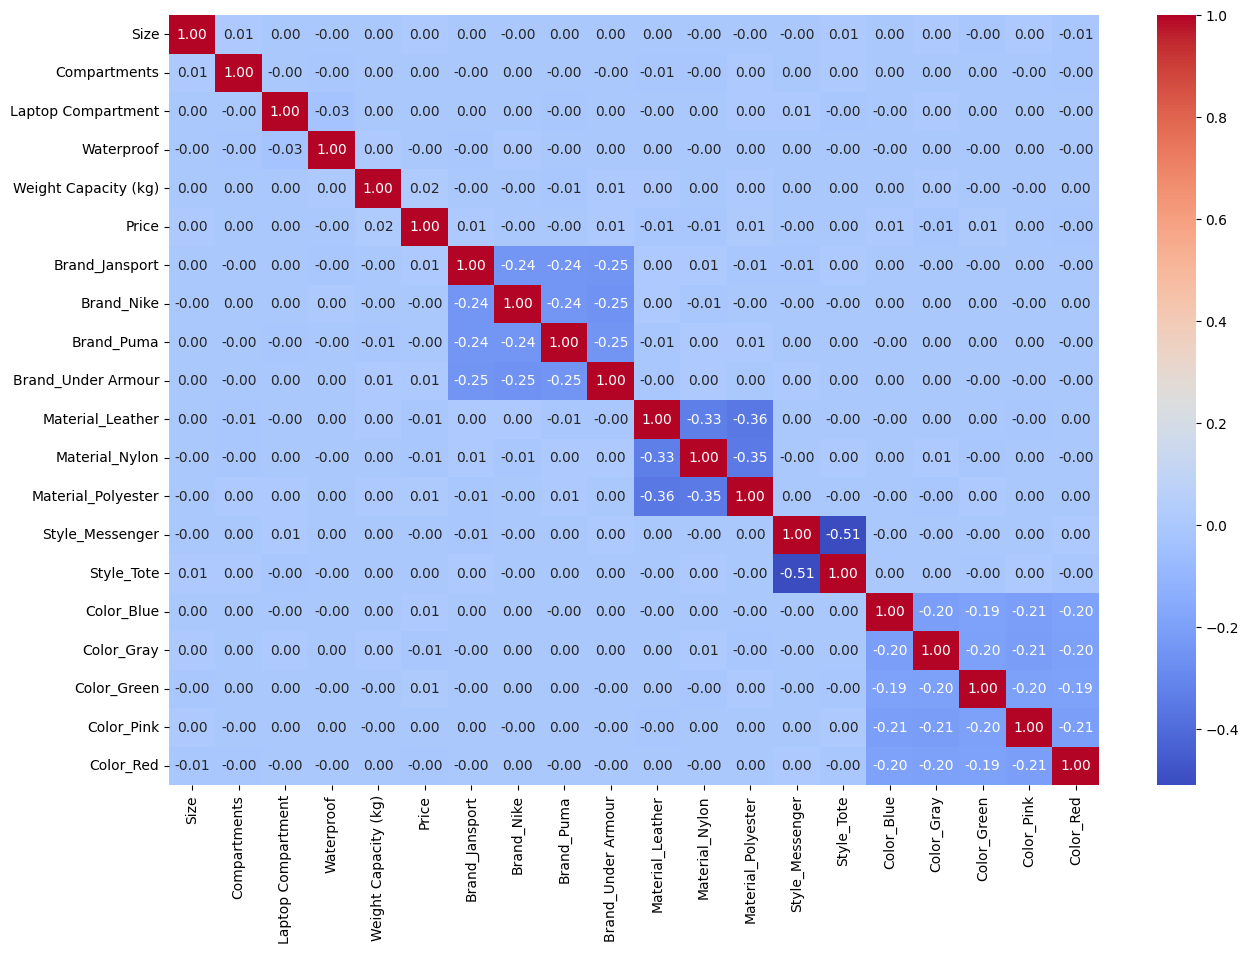

In [10]:
plt.figure(figsize=(15, 10))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

# Обработка

## Удаление id

In [11]:
df = df.drop(columns=['id'])
df

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Jansport,Leather,Medium,7.0,Yes,No,Tote,Black,11.611723,112.15875
1,Jansport,Canvas,Small,10.0,Yes,Yes,Messenger,Green,27.078537,68.88056
2,Under Armour,Leather,Small,2.0,Yes,No,Messenger,Red,16.643760,39.17320
3,Nike,Nylon,Small,8.0,Yes,No,Messenger,Green,12.937220,80.60793
4,Adidas,Canvas,Medium,1.0,Yes,Yes,Messenger,Green,17.749338,86.02312
...,...,...,...,...,...,...,...,...,...,...
299995,Adidas,Leather,Small,9.0,No,No,Tote,Blue,12.730812,129.99749
299996,Jansport,Leather,Large,6.0,No,Yes,Tote,Blue,26.633182,19.85819
299997,Puma,Canvas,Large,9.0,Yes,Yes,Backpack,Pink,11.898250,111.41364
299998,Adidas,Nylon,Small,1.0,No,Yes,Tote,Pink,6.175738,115.89080


## Обработка пропусков и выбросов

In [12]:
df.isna().sum()

Brand                   9705
Material                8347
Size                    6595
Compartments               0
Laptop Compartment      7444
Waterproof              7050
Style                   7970
Color                   9950
Weight Capacity (kg)     138
Price                      0
dtype: int64

### Обработка пропусков и выбросов Brand

In [13]:
df["Brand"].unique()

array(['Jansport', 'Under Armour', 'Nike', 'Adidas', 'Puma', nan],
      dtype=object)

Можно заметить, что нет абсолютно никакой связи между Brand и остальными признаками, так как все они примерно распределены поровну

In [14]:
for column in df.drop(columns=["Brand", "Weight Capacity (kg)", "Price"]).columns:
    print(pandas.crosstab(df['Brand'], df[column], normalize='index'))

Material        Canvas   Leather     Nylon  Polyester
Brand                                                
Adidas        0.235434  0.251712  0.237231   0.275623
Jansport      0.230415  0.253851  0.246883   0.268851
Nike          0.236797  0.256415  0.237174   0.269614
Puma          0.228923  0.247131  0.245303   0.278643
Under Armour  0.233948  0.249601  0.244132   0.272319
Size             Large    Medium     Small
Brand                                     
Adidas        0.333072  0.351584  0.315344
Jansport      0.335425  0.349285  0.315290
Nike          0.334011  0.348521  0.317468
Puma          0.337812  0.345699  0.316489
Under Armour  0.338751  0.342605  0.318644
Compartments      1.0       2.0       3.0       4.0       5.0       6.0   \
Brand                                                                      
Adidas        0.102968  0.103018  0.101287  0.103401  0.102052  0.090700   
Jansport      0.104394  0.103360  0.101327  0.105642  0.100613  0.090788   
Nike          0.1

Более того примерно поровну распределены даже значения в Brand

In [15]:
df['Brand'].dropna().value_counts(normalize=True)

Brand
Adidas          0.206952
Under Armour    0.206659
Nike            0.197509
Puma            0.195711
Jansport        0.193169
Name: proportion, dtype: float64

In [16]:
uniform_nan_filling(df, "Brand")

Пропусков осталось: 0
Распределение:
 Brand
Adidas          0.206933
Under Armour    0.206593
Nike            0.197507
Puma            0.195807
Jansport        0.193160
Name: proportion, dtype: float64


### Обработка пропусков и выбросов Material

In [17]:
df["Material"].unique()

array(['Leather', 'Canvas', 'Nylon', nan, 'Polyester'], dtype=object)

In [18]:
for column in df.drop(columns=["Material", "Weight Capacity (kg)", "Price"]).columns:
    print(pandas.crosstab(df['Material'], df[column], normalize='index'))

Brand        Adidas  Jansport      Nike      Puma  Under Armour
Material                                                       
Canvas     0.209208  0.190915  0.200576  0.192018      0.207282
Leather    0.206821  0.194522  0.201591  0.192315      0.204751
Nylon      0.202683  0.196960  0.193575  0.198462      0.208320
Polyester  0.208828  0.190418  0.194763  0.199824      0.206166
Size          Large    Medium     Small
Material                               
Canvas     0.341128  0.338560  0.320312
Leather    0.335242  0.350008  0.314751
Nylon      0.335925  0.348357  0.315718
Polyester  0.332670  0.351576  0.315754
Compartments      1.0       2.0       3.0       4.0       5.0       6.0   \
Material                                                                   
Canvas        0.102023  0.100200  0.101362  0.106655  0.100274  0.090598   
Leather       0.106911  0.104623  0.100496  0.105958  0.098112  0.090621   
Nylon         0.107418  0.102333  0.099188  0.105010  0.100265  0.089628

In [19]:
df['Material'].dropna().value_counts(normalize=True)

Material
Polyester    0.273030
Leather      0.251724
Nylon        0.242079
Canvas       0.233167
Name: proportion, dtype: float64

In [20]:
uniform_nan_filling(df, "Material")

Пропусков осталось: 0
Распределение:
 Material
Polyester    0.272907
Leather      0.251733
Nylon        0.242053
Canvas       0.233307
Name: proportion, dtype: float64


### Обработка пропусков и выбросов Size

In [21]:
df["Size"].unique()

array(['Medium', 'Small', 'Large', nan], dtype=object)

In [22]:
for column in df.drop(columns=["Size", "Weight Capacity (kg)", "Price"]).columns:
    print(pandas.crosstab(df['Size'], df[column], normalize='index'))

Brand     Adidas  Jansport      Nike      Puma  Under Armour
Size                                                        
Large   0.205276  0.193029  0.196395  0.197247      0.208053
Medium  0.209271  0.194100  0.198104  0.194375      0.204149
Small   0.206007  0.192362  0.198447  0.195636      0.207547
Material    Canvas   Leather     Nylon  Polyester
Size                                             
Large     0.236955  0.251037  0.241771   0.270237
Medium    0.227994  0.253704  0.242056   0.276245
Small     0.236172  0.250388  0.241320   0.272120
Compartments      1.0       2.0       3.0       4.0       5.0       6.0   \
Size                                                                       
Large         0.103261  0.101061  0.099551  0.104843  0.099531  0.091096   
Medium        0.105067  0.101437  0.103625  0.105421  0.101015  0.091270   
Small         0.106875  0.103063  0.099412  0.104452  0.100629  0.090581   

Compartments      7.0       8.0       9.0       10.0  
Size     

In [23]:
df['Size'].dropna().value_counts(normalize=True)

Size
Medium    0.347322
Large     0.336201
Small     0.316477
Name: proportion, dtype: float64

In [24]:
uniform_nan_filling(df, "Size")

Пропусков осталось: 0
Распределение:
 Size
Medium    0.34759
Large     0.33608
Small     0.31633
Name: proportion, dtype: float64


### Обработка пропусков и выбросов Laptop Compartment

In [25]:
df["Laptop Compartment"].unique()

array(['Yes', 'No', nan], dtype=object)

In [26]:
for column in df.drop(columns=["Laptop Compartment", "Weight Capacity (kg)", "Price"]).columns:
    print(pandas.crosstab(df['Laptop Compartment'], df[column], normalize='index'))

Brand                 Adidas  Jansport      Nike      Puma  Under Armour
Laptop Compartment                                                      
No                  0.208419  0.192783  0.197138  0.196604      0.205056
Yes                 0.205491  0.193883  0.198602  0.194665      0.207359
Material              Canvas   Leather     Nylon  Polyester
Laptop Compartment                                         
No                  0.234693  0.252881  0.241752   0.270674
Yes                 0.232550  0.250940  0.241995   0.274514
Size                   Large    Medium     Small
Laptop Compartment                              
No                  0.335675  0.348281  0.316044
Yes                 0.335879  0.347285  0.316835
Compartments            1.0       2.0       3.0       4.0       5.0   \
Laptop Compartment                                                     
No                  0.105024  0.100406  0.101544  0.103568  0.100191   
Yes                 0.104859  0.103174  0.100295  0.1062

In [27]:
df['Laptop Compartment'].dropna().value_counts(normalize=True)

Laptop Compartment
Yes    0.507055
No     0.492945
Name: proportion, dtype: float64

In [28]:
uniform_nan_filling(df, "Laptop Compartment")

Пропусков осталось: 0
Распределение:
 Laptop Compartment
Yes    0.50707
No     0.49293
Name: proportion, dtype: float64


### Обработка пропусков и выбросов Waterproof

In [29]:
df["Waterproof"].unique()

array(['No', 'Yes', nan], dtype=object)

In [30]:
for column in df.drop(columns=["Waterproof", "Weight Capacity (kg)", "Price"]).columns:
    print(pandas.crosstab(df['Waterproof'], df[column], normalize='index'))

Brand         Adidas  Jansport     Nike      Puma  Under Armour
Waterproof                                                     
No          0.207292  0.194363  0.19613  0.195992      0.206222
Yes         0.206791  0.191839  0.19889  0.195439      0.207041
Material      Canvas   Leather     Nylon  Polyester
Waterproof                                         
No          0.233701  0.251551  0.242267   0.272480
Yes         0.232906  0.252511  0.242151   0.272433
Size           Large    Medium     Small
Waterproof                              
No          0.336660  0.347283  0.316056
Yes         0.335562  0.347758  0.316680
Compartments      1.0       2.0       3.0       4.0       5.0       6.0   \
Waterproof                                                                 
No            0.103850  0.101323  0.100944  0.104395  0.099570  0.092012   
Yes           0.106404  0.102521  0.100974  0.105560  0.099847  0.090075   

Compartments      7.0       8.0       9.0       10.0  
Waterproof  

In [31]:
df['Waterproof'].dropna().value_counts(normalize=True)

Waterproof
Yes    0.505469
No     0.494531
Name: proportion, dtype: float64

In [32]:
uniform_nan_filling(df, "Waterproof")

Пропусков осталось: 0
Распределение:
 Waterproof
Yes    0.505337
No     0.494663
Name: proportion, dtype: float64


### Обработка пропусков и выбросов Style

In [33]:
df["Style"].unique()

array(['Tote', 'Messenger', nan, 'Backpack'], dtype=object)

In [34]:
for column in df.drop(columns=["Style", "Weight Capacity (kg)", "Price"]).columns:
    print(pandas.crosstab(df['Style'], df[column], normalize='index'))

Brand        Adidas  Jansport      Nike      Puma  Under Armour
Style                                                          
Backpack   0.205592  0.194446  0.200632  0.194224      0.205106
Messenger  0.209175  0.190991  0.195579  0.196539      0.207716
Tote       0.206552  0.194462  0.196176  0.196268      0.206542
Material     Canvas   Leather     Nylon  Polyester
Style                                             
Backpack   0.235467  0.250367  0.240374   0.273792
Messenger  0.231838  0.253311  0.241395   0.273455
Tote       0.232517  0.251473  0.244638   0.271373
Size          Large    Medium     Small
Style                                  
Backpack   0.334683  0.346136  0.319180
Messenger  0.336356  0.346123  0.317522
Tote       0.336912  0.350223  0.312866
Compartments      1.0       2.0       3.0       4.0       5.0       6.0   \
Style                                                                      
Backpack      0.106735  0.103045  0.102664  0.105519  0.101035  0.090101 

In [35]:
df['Style'].dropna().value_counts(normalize=True)

Style
Messenger    0.342537
Tote         0.333658
Backpack     0.323806
Name: proportion, dtype: float64

In [36]:
uniform_nan_filling(df, "Style")

Пропусков осталось: 0
Распределение:
 Style
Messenger    0.342417
Tote         0.333837
Backpack     0.323747
Name: proportion, dtype: float64


### Обработка пропусков и выбросов Color

In [37]:
df["Color"].unique()

array(['Black', 'Green', 'Red', 'Blue', 'Gray', 'Pink', nan], dtype=object)

In [38]:
for column in df.drop(columns=["Color", "Weight Capacity (kg)", "Price"]).columns:
    print(pandas.crosstab(df['Color'], df[column], normalize='index'))

Brand    Adidas  Jansport      Nike      Puma  Under Armour
Color                                                      
Black  0.208698  0.191944  0.196774  0.194079      0.208504
Blue   0.204524  0.195501  0.197954  0.194835      0.207185
Gray   0.202844  0.192104  0.198309  0.197872      0.208870
Green  0.207886  0.192235  0.198767  0.195749      0.205364
Pink   0.208319  0.195570  0.195783  0.195744      0.204585
Red    0.210106  0.191830  0.198458  0.194329      0.205278
Material    Canvas   Leather     Nylon  Polyester
Color                                            
Black     0.236491  0.252426  0.240092   0.270991
Blue      0.232884  0.251845  0.242967   0.272304
Gray      0.230708  0.253123  0.247017   0.269153
Green     0.230113  0.252878  0.240741   0.276269
Pink      0.234185  0.248791  0.242116   0.274908
Red       0.234821  0.253330  0.238696   0.273153
Size      Large    Medium     Small
Color                              
Black  0.334102  0.352171  0.313726
Blue   0.336

In [39]:
df['Color'].dropna().value_counts(normalize=True)

Color
Pink     0.178211
Gray     0.173349
Blue     0.165823
Red      0.162796
Green    0.159924
Black    0.159897
Name: proportion, dtype: float64

In [40]:
uniform_nan_filling(df, "Color")

Пропусков осталось: 0
Распределение:
 Color
Pink     0.178263
Gray     0.173300
Blue     0.165993
Red      0.162703
Green    0.160007
Black    0.159733
Name: proportion, dtype: float64


### Обработка пропусков и выбросов Weight Capacity (kg)

In [41]:
df["Weight Capacity (kg)"].describe()

count    299862.000000
mean         18.029994
std           6.966914
min           5.000000
25%          12.097867
50%          18.068614
75%          24.002375
max          30.000000
Name: Weight Capacity (kg), dtype: float64

In [42]:
for column in df.drop(columns=["Weight Capacity (kg)", "Price"]).columns:
    print(pandas.crosstab(df['Weight Capacity (kg)'], df[column], normalize='index'))

Brand                   Adidas  Jansport      Nike      Puma  Under Armour
Weight Capacity (kg)                                                      
5.000000              0.199720  0.188287  0.191554  0.202753      0.217685
5.004444              0.000000  0.000000  0.000000  0.000000      1.000000
5.008382              0.000000  1.000000  0.000000  0.000000      0.000000
5.009731              1.000000  0.000000  0.000000  0.000000      0.000000
5.010086              0.500000  0.000000  0.000000  0.000000      0.500000
...                        ...       ...       ...       ...           ...
29.996888             1.000000  0.000000  0.000000  0.000000      0.000000
29.997986             0.000000  0.000000  0.750000  0.250000      0.000000
29.998925             0.000000  0.000000  0.000000  1.000000      0.000000
29.999796             0.000000  0.000000  0.000000  1.000000      0.000000
30.000000             0.205405  0.183784  0.172973  0.156757      0.281081

[181596 rows x 5 columns

In [43]:
df['Weight Capacity (kg)'].dropna().value_counts(normalize=True)

Weight Capacity (kg)
5.000000     0.014293
30.000000    0.000617
11.898250    0.000410
22.898382    0.000387
14.908437    0.000337
               ...   
29.697814    0.000003
17.917185    0.000003
21.844401    0.000003
24.234022    0.000003
21.829597    0.000003
Name: proportion, Length: 181596, dtype: float64

In [44]:
df["Weight Capacity (kg)"] = df['Weight Capacity (kg)'].fillna(df['Weight Capacity (kg)'].mean())

print(df["Weight Capacity (kg)"].isna().sum())
print(df["Weight Capacity (kg)"].describe())

0
count    300000.000000
mean         18.029994
std           6.965312
min           5.000000
25%          12.099086
50%          18.064618
75%          24.001145
max          30.000000
Name: Weight Capacity (kg), dtype: float64


### Итог

In [45]:
df.isna().sum()

Brand                   0
Material                0
Size                    0
Compartments            0
Laptop Compartment      0
Waterproof              0
Style                   0
Color                   0
Weight Capacity (kg)    0
Price                   0
dtype: int64

## Обработка категориальных признаков

### One hot encoding

In [46]:
df = pandas.get_dummies(
    df,
    columns=["Brand", "Material", "Style", "Color"],
    drop_first=True,
    dtype=int
)
df

,Size,Compartments,Laptop Compartment,Waterproof,Weight Capacity (kg),Price,Brand_Jansport,Brand_Nike,Brand_Puma,Brand_Under Armour,Material_Leather,Material_Nylon,Material_Polyester,Style_Messenger,Style_Tote,Color_Blue,Color_Gray,Color_Green,Color_Pink,Color_Red
0,Medium,7.0,Yes,No,11.611723,112.15875,1,0,0,0,1,0,0,0,1,0,0,0,0,0
1,Small,10.0,Yes,Yes,27.078537,68.88056,1,0,0,0,0,0,0,1,0,0,0,1,0,0
2,Small,2.0,Yes,No,16.643760,39.17320,0,0,0,1,1,0,0,1,0,0,0,0,0,1
3,Small,8.0,Yes,No,12.937220,80.60793,0,1,0,0,0,1,0,1,0,0,0,1,0,0
4,Medium,1.0,Yes,Yes,17.749338,86.02312,0,0,0,0,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,Small,9.0,No,No,12.730812,129.99749,0,0,0,0,1,0,0,0,1,1,0,0,0,0
299996,Large,6.0,No,Yes,26.633182,19.85819,1,0,0,0,1,0,0,0,1,1,0,0,0,0
299997,Large,9.0,Yes,Yes,11.898250,111.41364,0,0,1,0,0,0,0,0,0,0,0,0,1,0
299998,Small,1.0,No,Yes,6.175738,115.89080,0,0,0,0,0,1,0,0,1,0,0,0,1,0


### Label encoding

In [47]:
df["Size"] = df["Size"].map({
    "Small": 1,
    "Medium": 2,
    "Large": 3
}).astype(int)
df["Laptop Compartment"] = df["Laptop Compartment"].map({"Yes": 1, "No": 0})
df["Waterproof"] = df["Waterproof"].map({"Yes": 1, "No": 0})
df

,Size,Compartments,Laptop Compartment,Waterproof,Weight Capacity (kg),Price,Brand_Jansport,Brand_Nike,Brand_Puma,Brand_Under Armour,Material_Leather,Material_Nylon,Material_Polyester,Style_Messenger,Style_Tote,Color_Blue,Color_Gray,Color_Green,Color_Pink,Color_Red
0,2,7.0,1,0,11.611723,112.15875,1,0,0,0,1,0,0,0,1,0,0,0,0,0
1,1,10.0,1,1,27.078537,68.88056,1,0,0,0,0,0,0,1,0,0,0,1,0,0
2,1,2.0,1,0,16.643760,39.17320,0,0,0,1,1,0,0,1,0,0,0,0,0,1
3,1,8.0,1,0,12.937220,80.60793,0,1,0,0,0,1,0,1,0,0,0,1,0,0
4,2,1.0,1,1,17.749338,86.02312,0,0,0,0,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,1,9.0,0,0,12.730812,129.99749,0,0,0,0,1,0,0,0,1,1,0,0,0,0
299996,3,6.0,0,1,26.633182,19.85819,1,0,0,0,1,0,0,0,1,1,0,0,0,0
299997,3,9.0,1,1,11.898250,111.41364,0,0,1,0,0,0,0,0,0,0,0,0,1,0
299998,1,1.0,0,1,6.175738,115.89080,0,0,0,0,0,1,0,0,1,0,0,0,1,0


## Определение целевой переменной

In [48]:
Y = df["Price"]
df.drop(["Price"], inplace=True, axis=1)
Y

0         112.15875
1          68.88056
2          39.17320
3          80.60793
4          86.02312
            ...    
299995    129.99749
299996     19.85819
299997    111.41364
299998    115.89080
299999     26.72762
Name: Price, Length: 300000, dtype: float64

## Нормализация

In [49]:
df = (df - df.min()) / (df.max() - df.min())
df

,Size,Compartments,Laptop Compartment,Waterproof,Weight Capacity (kg),Brand_Jansport,Brand_Nike,Brand_Puma,Brand_Under Armour,Material_Leather,Material_Nylon,Material_Polyester,Style_Messenger,Style_Tote,Color_Blue,Color_Gray,Color_Green,Color_Pink,Color_Red
0,0.5,0.666667,1.0,0.0,0.264469,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.000000,1.0,1.0,0.883141,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.111111,1.0,0.0,0.465750,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.777778,1.0,0.0,0.317489,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.5,0.000000,1.0,1.0,0.509974,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,0.0,0.888889,0.0,0.0,0.309232,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
299996,1.0,0.555556,0.0,1.0,0.865327,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
299997,1.0,0.888889,1.0,1.0,0.275930,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
299998,0.0,0.000000,0.0,1.0,0.047030,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# Обучение модели

## Разбиение на тренировочную и тестовую

In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(df, Y, test_size=0.3, random_state=42)

## Обучение модели CatBoostRegressor

In [51]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    early_stopping_rounds=50
)

model.fit(
    X_train, Y_train,
    eval_set=(X_test, Y_test)
)

0:	learn: 33.8216219	test: 33.7369979	best: 33.7369979 (0)	total: 66.1ms	remaining: 1m 6s
1:	learn: 33.8159972	test: 33.7342588	best: 33.7342588 (1)	total: 79.1ms	remaining: 39.5s
2:	learn: 33.8117948	test: 33.7316470	best: 33.7316470 (2)	total: 91.7ms	remaining: 30.5s
3:	learn: 33.8070532	test: 33.7296556	best: 33.7296556 (3)	total: 105ms	remaining: 26.1s
4:	learn: 33.8051758	test: 33.7279120	best: 33.7279120 (4)	total: 115ms	remaining: 22.9s
5:	learn: 33.8010666	test: 33.7254864	best: 33.7254864 (5)	total: 130ms	remaining: 21.5s
6:	learn: 33.7968637	test: 33.7237935	best: 33.7237935 (6)	total: 145ms	remaining: 20.5s
7:	learn: 33.7932457	test: 33.7216185	best: 33.7216185 (7)	total: 157ms	remaining: 19.5s
8:	learn: 33.7879129	test: 33.7202710	best: 33.7202710 (8)	total: 170ms	remaining: 18.7s
9:	learn: 33.7846678	test: 33.7192842	best: 33.7192842 (9)	total: 183ms	remaining: 18.1s
10:	learn: 33.7814080	test: 33.7179950	best: 33.7179950 (10)	total: 196ms	remaining: 17.6s
11:	learn: 33.77

## Предсказывание

In [52]:
Y_pred = model.predict(X_test)

## Оценка результатов

In [53]:
mae = mean_absolute_error(Y_test, Y_pred)
print("MAE:", mae)

rmse = numpy.sqrt(mean_squared_error(Y_test, Y_pred))
print("RMSE:", rmse)

MAE: 33.70188270011461
RMSE: 38.978187493723766


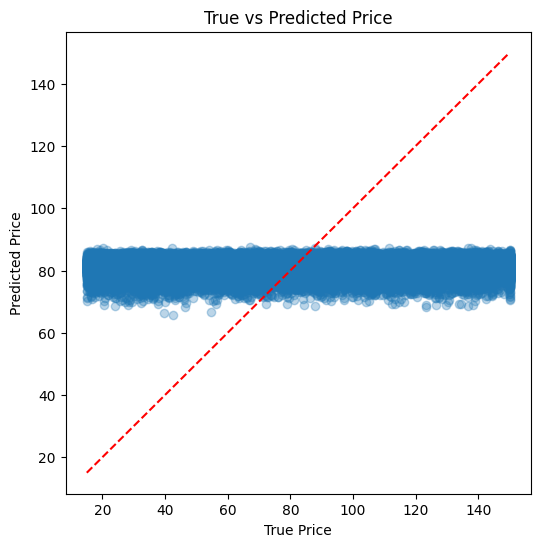

In [54]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, Y_pred, alpha=0.3)
plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    'r--')
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("True vs Predicted Price")
plt.show()